# Tokenizer version 1 
using regex 


In [11]:
#load text sample

with open("the-verdict.txt", encoding = "utf-8") as f: 
    raw_text = f.read()
print("Number of characters :", {len(raw_text)})
print(raw_text[:99])

Number of characters : {20479}
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


#### Spliting text into individual components 

In [12]:
#we want to split the text and punctuation to get a list of tokens (words)
import re

text = "Hello, world. Is this-- a test?"

tokens = re.findall(r"\w+|--|[^\w\s]", text)
print(tokens) #it returns all wors and puncuation for 10 individual tokens. 

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


In [13]:
#run on the sample text
preprocessed = re.findall(r"\w+|--|[^\w\s]", raw_text)
print(len(preprocessed))
print(preprocessed[:30]) 


4730
['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


### Convert tokens to token ID 
need to turn the string into an integer representation to produce the token ID. 
(this before the embedding vectors )
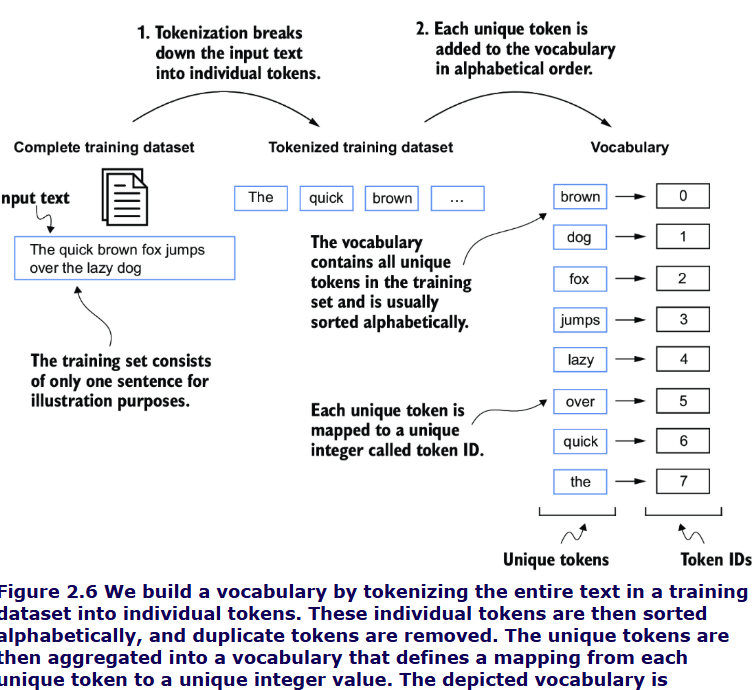

In [14]:
all_words = sorted(set(preprocessed)) #sorting alphabetically and removing duplicates
vocab_size = len(all_words)
print("Vocabulary size:", vocab_size)

#creating a dictionary maping integer to token
vocab = {token: integer for integer, token in enumerate(all_words)}
for i, item in enumerate(vocab.items()):
    print (item)
    if i >= 50:
        break

Vocabulary size: 1149
('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('-', 6)
('--', 7)
('.', 8)
(':', 9)
(';', 10)
('?', 11)
('A', 12)
('Ah', 13)
('Among', 14)
('And', 15)
('Are', 16)
('Arrt', 17)
('As', 18)
('At', 19)
('Be', 20)
('Begin', 21)
('Burlington', 22)
('But', 23)
('By', 24)
('Carlo', 25)
('Chicago', 26)
('Claude', 27)
('Come', 28)
('Croft', 29)
('Destroyed', 30)
('Devonshire', 31)
('Don', 32)
('Dubarry_', 33)
('Emperors', 34)
('Florence', 35)
('For', 36)
('Gallery', 37)
('Gideon', 38)
('Gisburn', 39)
('Gisburns', 40)
('Grafton', 41)
('Greek', 42)
('Grindle', 43)
('Grindles', 44)
('HAD', 45)
('Had', 46)
('Hang', 47)
('Has', 48)
('He', 49)
('Her', 50)


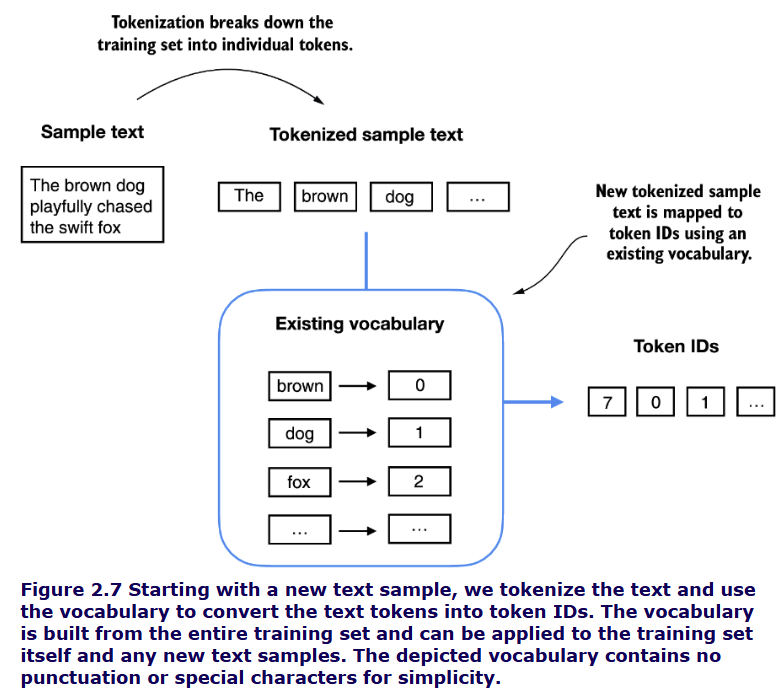 vocab mapped to actual text 

Also need a way to inverse version of vocab map to turn token IDS into text 

### Full tokenizer class 

In [15]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        #inverse map 
        self.int_to_str = {integer: token for token, integer in vocab.items()}

    #word -> embeddings 
    def encode(self, text):
        preprocessed = re.split(r'([, .? !"()\']| -- |\s)', text)
        preprocessed = [
            #cleanup 
            item. strip() for item in preprocessed if item.strip()
        ]
        #loop through clean words and convert to integer ID 
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    #embeddings -> word
    def decode(self,ids):
        #looks up word/token for each integer ID and joins them togther with space between
        text = " ".join([self.int_to_str[i] for i in ids])
        
        #remove space before punctuation (cleanup)
        text = re.sub(r'\s+([, .?! "()\'])', r'\1', text)
        return text


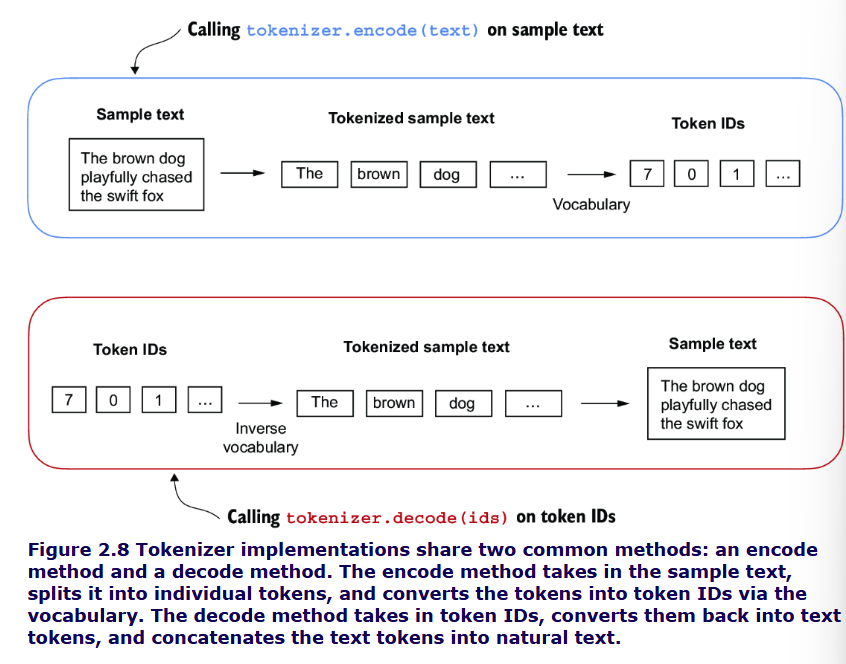

In [16]:
tokenizer = SimpleTokenizerV1(vocab)
text = """"It's the last he painted, you know," Mrs. Gisburn said with pardonable pride."""
ids = tokenizer.encode(text)
print(ids)

print(tokenizer.decode(ids))

[1, 57, 2, 868, 1007, 616, 547, 761, 5, 1145, 610, 5, 1, 68, 8, 39, 869, 1127, 770, 811, 8]
" It' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.


A large issue is what if the word isn't part of the vocab map

# Tokenizer version 2 
using special context token to handle unknown words 
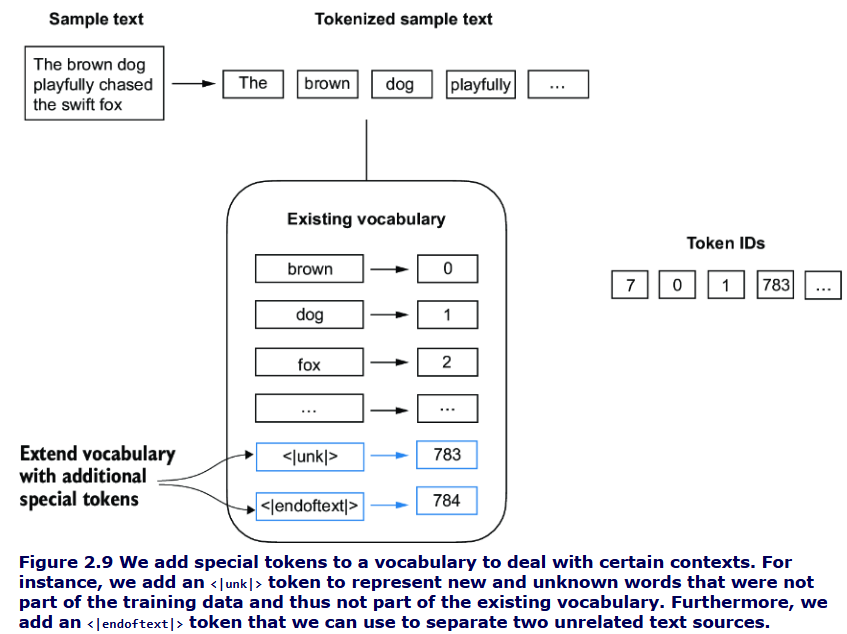
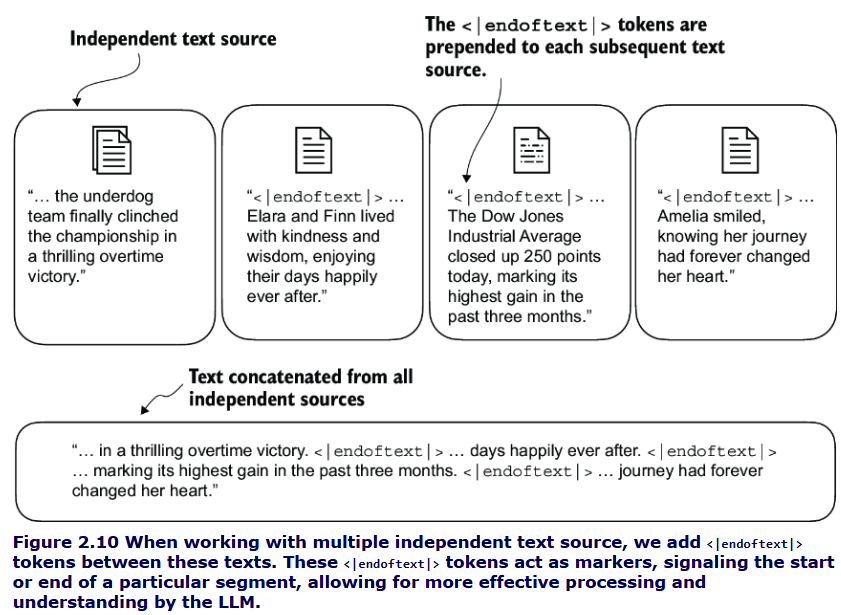


In [17]:
#adding in the endoftext and unk tokens 

all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>","<|unk|>"])
vocab = {token: integer for integer, token in enumerate(all_tokens)}

print(len(vocab.items()))

#see new special tokens are added to the end of the vocab list
for i, item in enumerate(list(vocab.items())[-5:]):
    print(item)

1151
('younger', 1146)
('your', 1147)
('yourself', 1148)
('<|endoftext|>', 1149)
('<|unk|>', 1150)


In [22]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab 
        self.int_to_str = {i: s for s, i in vocab.items()}
    
    def encode(self, text):
        preprocessed = re.split(r'([, .?!"()\']| -- |\s)', text)
        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ]
        preprocessed = [item if item in self.str_to_int else "<|unk|>" for item in preprocessed]

        ids = [self.str_to_int[s] for s in preprocessed]
        return ids
    
    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        text = re.sub(r'\s+([, .?! "()\'])', r'\1', text)
        return text

In [25]:
text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."
text = " <|endoftext|> ".join((text1,text2))
print (text)

tokenizer = SimpleTokenizerV2(vocab)
print(tokenizer.encode(text))
print(tokenizer.decode(tokenizer.encode(text)))

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.
[1150, 5, 375, 1145, 641, 994, 11, 1149, 56, 1007, 975, 1003, 737, 1007, 1150, 8]
<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.
